In [1]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric

# Daten laden
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()
sex_train = pd.read_csv('../data/sex_train.csv').squeeze()
sex_test = pd.read_csv('../data/sex_test.csv').squeeze()

print("Daten geladen.")


pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[inFairness]'


Daten geladen.


In [2]:
# Modell neu trainieren
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# AIF360 Dataset vorbereiten
test_df = X_test.copy()
test_df['income'] = y_test.values
test_df['sex'] = sex_test.values

pred_df = X_test.copy()
pred_df['income'] = y_pred
pred_df['sex'] = sex_test.values

dataset_true = BinaryLabelDataset(
    df=test_df,
    label_names=['income'],
    protected_attribute_names=['sex']
)

dataset_pred = BinaryLabelDataset(
    df=pred_df,
    label_names=['income'],
    protected_attribute_names=['sex']
)

print("AIF360 Datasets erstellt.")

AIF360 Datasets erstellt.


In [3]:
# Fairness-Metriken berechnen
metric = ClassificationMetric(
    dataset_true,
    dataset_pred,
    unprivileged_groups=[{'sex': 0}],
    privileged_groups=[{'sex': 1}]
)

# Statistical Parity
sp = metric.statistical_parity_difference()

# Disparate Impact Ratio
di = metric.disparate_impact()

# Equalized Odds
eo_tpr = metric.true_positive_rate_difference()
eo_fpr = metric.false_positive_rate_difference()

print("Statistical Parity Difference:", round(sp, 4))
print("Disparate Impact Ratio:", round(di, 4))
print("Equalized Odds — TPR Difference:", round(eo_tpr, 4))
print("Equalized Odds — FPR Difference:", round(eo_fpr, 4))


Statistical Parity Difference: -0.1822
Disparate Impact Ratio: 0.3252
Equalized Odds — TPR Difference: -0.0699
Equalized Odds — FPR Difference: -0.0877


In [4]:
# Ergebnisse speichern
results_fairness = pd.DataFrame({
    'Metrik': [
        'Statistical Parity Difference',
        'Disparate Impact Ratio',
        'Equalized Odds TPR Difference',
        'Equalized Odds FPR Difference'
    ],
    'Wert': [sp, di, eo_tpr, eo_fpr],
    'Schwellenwert': [0, 0.8, 0, 0],
    'Interpretation': [
        'Negativ = Frauen benachteiligt',
        'Unter 0.8 = diskriminierend',
        'Negativ = Frauen benachteiligt',
        'Negativ = Frauen benachteiligt'
    ]
})

results_fairness.to_csv('../results/tables/fairness_baseline.csv', index=False)
print(results_fairness)


                          Metrik      Wert  Schwellenwert  \
0  Statistical Parity Difference -0.182170            0.0   
1         Disparate Impact Ratio  0.325183            0.8   
2  Equalized Odds TPR Difference -0.069924            0.0   
3  Equalized Odds FPR Difference -0.087672            0.0   

                   Interpretation  
0  Negativ = Frauen benachteiligt  
1     Unter 0.8 = diskriminierend  
2  Negativ = Frauen benachteiligt  
3  Negativ = Frauen benachteiligt  


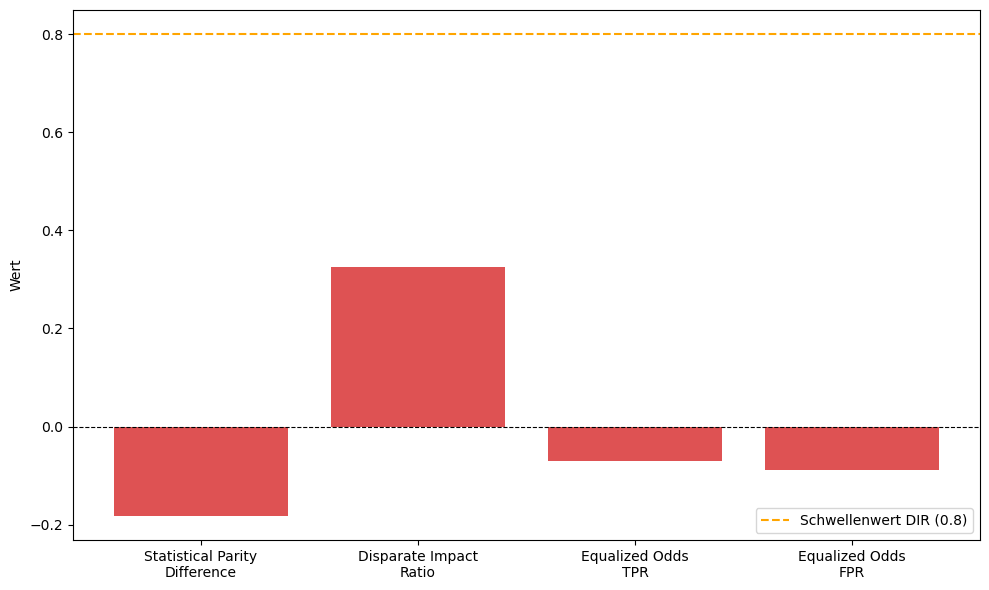

Gespeichert.


In [5]:
# Visualisierung Fairness-Metriken Baseline
import matplotlib.pyplot as plt
import numpy as np

metriken = ['Statistical Parity\nDifference', 'Disparate Impact\nRatio', 
            'Equalized Odds\nTPR', 'Equalized Odds\nFPR']
werte = [-0.1822, 0.3252, -0.0699, -0.0877]
schwellenwerte = [0, 0.8, 0, 0]

farben = ['#d62728' if w < s else '#2ca02c' 
          for w, s in zip(werte, schwellenwerte)]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metriken, werte, color=farben, alpha=0.8)

# Schwellenwerte einzeichnen
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(y=0.8, color='orange', linewidth=1.5, 
           linestyle='--', label='Schwellenwert DIR (0.8)')

ax.set_ylabel('Wert')
# ax.set_title('Fairness-Metriken: Baseline-Modell')
ax.legend()

plt.tight_layout()
plt.savefig('../results/figures/fairness_baseline.png', dpi=150)
plt.show()
print("Gespeichert.")